<a href="https://colab.research.google.com/github/lydiadipaola/grand-isle-water-level-ml/blob/main/NOAA_2021_RandFor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Grand Isle, Louisiana: Short-Term Water-Level Prediction

Objective: Predict one-hour-ahead coastal water levels at NOAA station 8761724 (Grand Isle, Louisiana) using historical water-level observations.

Data: NOAA hourly water-level observations, 2021.

Predictors: Water levels lagged by 1, 2, 3, 6, 12, and 24 hours.

Target: Water level one hour ahead.

Validation: Chronological 80/20 train-test split.

Evaluation: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R².

Overview: This project evaluates whether machine-learning and statistical models can use recent water-level observations to predict short-term coastal water-level variability.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
url = "https://api.tidesandcurrents.noaa.gov/api/prod/datagetter?begin_date=20210101&end_date=20211231&station=8761724&product=hourly_height&datum=STND&time_zone=gmt&units=metric&format=csv"

df = pd.read_csv(url)

df.head()

,Date Time,Water Level,Sigma,I,L
0,2021-01-01 00:00,2.424,0.000,0,0
1,2021-01-01 01:00,2.483,0.009,0,0
2,2021-01-01 02:00,2.514,0.007,0,0
3,2021-01-01 03:00,2.550,0.005,0,0
4,2021-01-01 04:00,2.563,0.006,0,0


In [ ]:
# | Column          | Description                                                                                                     | Use in project?               |
# | --------------- | --------------------------------------------------------------------------------------------------------------- | ----------------------------- |
# | **Date Time**   | Date and time of the water-level observation, in GMT/UTC                                                        | ✅ Yes                         |
# | **Water Level** | Observed water level at Grand Isle, measured in meters relative to the **STND tidal datum**                     | 🎯 **Yes — target variable**  |
# | **Sigma**       | Estimated standard deviation/uncertainty of the water-level measurement                                         | ❌ Not initially               |
# | **I**           | NOAA's **inferred** data flag; indicates whether the value was inferred/estimated rather than directly observed | ⚠️ Useful for quality control |
# | **L**           | NOAA's **low-quality** data flag                                                                                | ⚠️ Useful for quality control |


Columns in dataset:
['Date Time', 'Water Level', 'Sigma', 'I', 'L']

Dataset shape:
(8760, 5)

Descriptive statistics:


,Water Level,Sigma,I,L
count,8760.000000,8760.000000,8760.000000,8760.000000
mean,2.166879,0.004921,0.000114,0.000228
std,0.190520,0.003226,0.010684,0.015109
min,1.569000,0.000000,0.000000,0.000000
25%,2.040000,0.003000,0.000000,0.000000
50%,2.172000,0.004000,0.000000,0.000000
75%,2.292000,0.006000,0.000000,0.000000
max,3.681000,0.045000,1.000000,1.000000



Missing values:


,0
Date Time,0
Water Level,0
Sigma,0
I,0
L,0


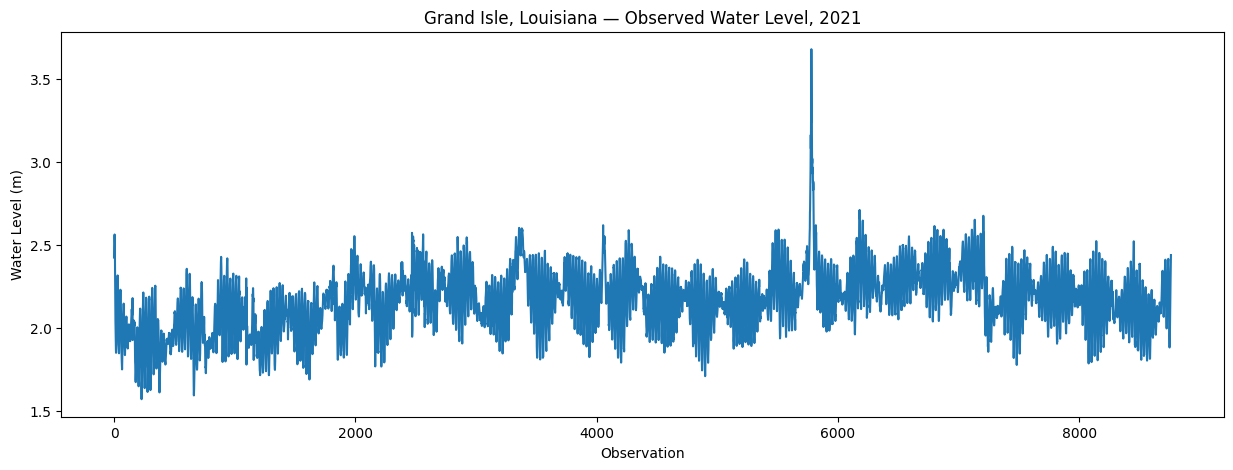

In [ ]:
# Clean column names
df.columns = df.columns.str.strip()

# Show the exact column names
print("Columns in dataset:")
print(df.columns.tolist())

# Dataset size
print("\nDataset shape:")
print(df.shape)

# Descriptive statistics
print("\nDescriptive statistics:")
display(df.describe())

# Missing values
print("\nMissing values:")
display(df.isna().sum())

# Plot water level
plt.figure(figsize=(15, 5))
plt.plot(df["Water Level"])

plt.title("Grand Isle, Louisiana — Observed Water Level, 2021")
plt.xlabel("Observation")
plt.ylabel("Water Level (m)")
plt.show()

In [ ]:
# Make a copy for ML preparation
ml_df = df.copy()

# Convert date/time to a proper datetime variable
ml_df["Date Time"] = pd.to_datetime(ml_df["Date Time"])

# Sort chronologically
ml_df = ml_df.sort_values("Date Time").reset_index(drop=True)

# Create previous-water-level predictors
ml_df["level_1h"] = ml_df["Water Level"].shift(1)
ml_df["level_2h"] = ml_df["Water Level"].shift(2)
ml_df["level_3h"] = ml_df["Water Level"].shift(3)
ml_df["level_6h"] = ml_df["Water Level"].shift(6)
ml_df["level_12h"] = ml_df["Water Level"].shift(12)
ml_df["level_24h"] = ml_df["Water Level"].shift(24)

# Create our prediction target:
# water level one hour in the future
ml_df["target"] = ml_df["Water Level"].shift(-1)

# Remove rows created by the lagging process
ml_df = ml_df.dropna().reset_index(drop=True)

# Look at the resulting dataset
ml_df.head()

,Date Time,Water Level,Sigma,I,L,level_1h,level_2h,level_3h,level_6h,level_12h,level_24h,target
0,2021-01-02 00:00:00,2.177,0.014,0,0,2.109,2.050,2.018,1.885,2.010,2.424,2.232
1,2021-01-02 01:00:00,2.232,0.007,0,0,2.177,2.109,2.050,1.898,1.951,2.483,2.256
2,2021-01-02 02:00:00,2.256,0.011,0,0,2.232,2.177,2.109,1.960,1.890,2.514,2.284
3,2021-01-02 03:00:00,2.284,0.010,0,0,2.256,2.232,2.177,2.018,1.864,2.550,2.306
4,2021-01-02 04:00:00,2.306,0.013,0,0,2.284,2.256,2.232,2.050,1.849,2.563,2.316


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=ml_df)

https://docs.google.com/spreadsheets/d/1__7L5gF-a3UdpFJWxZ1RKNQrz4NlFr89-Do_szBPU1E/edit#gid=0


In [ ]:
print("Original observations:", len(df))
print("ML observations:", len(ml_df))
print("\nML columns:")
print(ml_df.columns.tolist())

Original observations: 8760
ML observations: 8735

ML columns:
['Date Time', 'Water Level', 'Sigma', 'I', 'L', 'level_1h', 'level_2h', 'level_3h', 'level_6h', 'level_12h', 'level_24h', 'target']


In [ ]:
# Select the variables the model will use
features = [
    "level_1h",
    "level_2h",
    "level_3h",
    "level_6h",
    "level_12h",
    "level_24h"
]

X = ml_df[features]
y = ml_df["target"]

print("Predictors:", features)
print("Target: water level one hour ahead")
print("X shape:", X.shape)
print("y shape:", y.shape)

Predictors: ['level_1h', 'level_2h', 'level_3h', 'level_6h', 'level_12h', 'level_24h']
Target: water level one hour ahead
X shape: (8735, 6)
y shape: (8735,)


In [ ]:
# Chronological train/test split
split = int(len(ml_df) * 0.80)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nTraining period:")
print(ml_df["Date Time"].iloc[0], "to", ml_df["Date Time"].iloc[split - 1])

print("\nTesting period:")
print(ml_df["Date Time"].iloc[split], "to", ml_df["Date Time"].iloc[-1])

Training observations: 6988
Testing observations: 1747

Training period:
2021-01-02 00:00:00 to 2021-10-20 03:00:00

Testing period:
2021-10-20 04:00:00 to 2021-12-31 22:00:00


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create the model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
# Calculate model performance
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.3f} m")
print(f"RMSE: {rmse:.3f} m")
print(f"R²:   {r2:.3f}")

MAE:  0.023 m
RMSE: 0.032 m
R²:   0.966


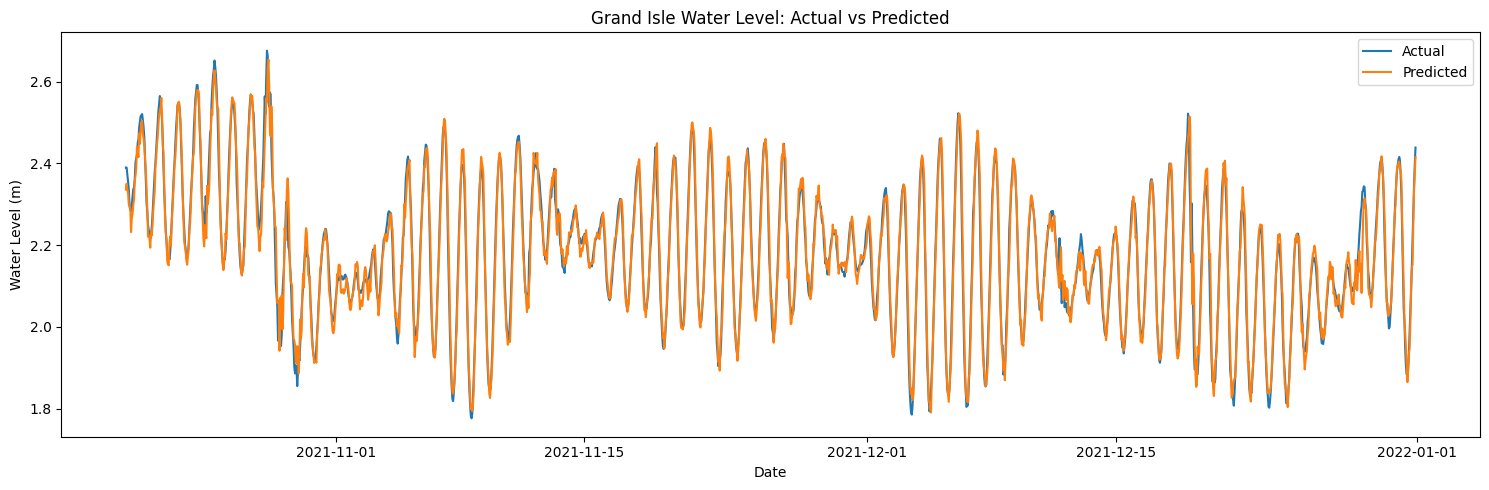

In [ ]:
# Create a results dataframe
results = pd.DataFrame({
    "Date Time": ml_df["Date Time"].iloc[split:],
    "Actual": y_test.values,
    "Predicted": y_pred
})

# Plot actual vs predicted water levels
plt.figure(figsize=(15, 5))

plt.plot(
    results["Date Time"],
    results["Actual"],
    label="Actual"
)

plt.plot(
    results["Date Time"],
    results["Predicted"],
    label="Predicted"
)

plt.title("Grand Isle Water Level: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Water Level (m)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
rf_importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

display(rf_importance)

,Feature,Importance
0,level_1h,0.856207
5,level_24h,0.073987
3,level_6h,0.026840
2,level_3h,0.021449
4,level_12h,0.013883
1,level_2h,0.007635


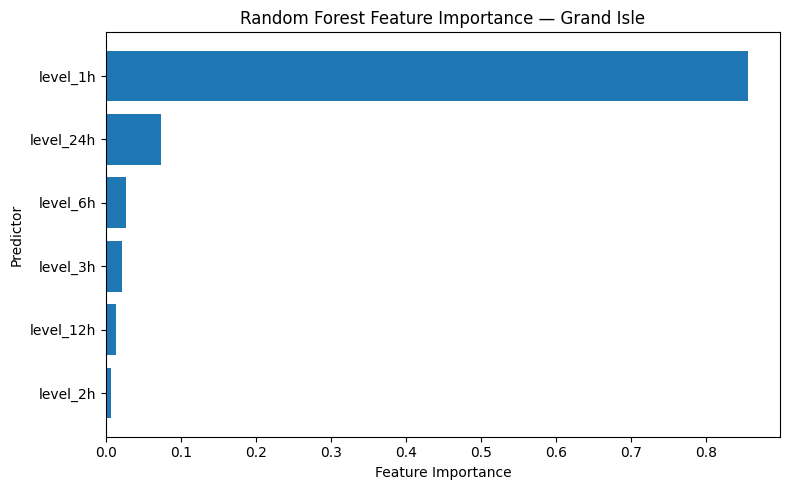

In [ ]:
plt.figure(figsize=(8, 5))

plt.barh(
    rf_importance["Feature"],
    rf_importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Predictor")
plt.title("Random Forest Feature Importance — Grand Isle")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

The Random Forest model relied predominantly on the one-hour lagged water level (level_1h), which accounted for approximately 85.6% of total feature importance. The 24-hour lag (level_24h) was the second most influential predictor at approximately 7.4%, while the remaining lagged variables each contributed less than 3%. This indicates that the most recent observation provided the majority of predictive information for one-hour-ahead water-level forecasting, with the previous daily cycle providing additional information.